In [4]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

import shap

In [5]:
df = pd.read_csv("../data/alzheimers_disease_data.csv")
print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
df.head()

Dataset loaded successfully!
Dataset shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,...,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,...,0,0,0.014691,0,0,1,1,0,0,XXXConfid


In [6]:
X = df.drop(["Diagnosis", "DoctorInCharge", "PatientID"], axis=1)
y = df["Diagnosis"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget Classes:")
print(y.value_counts())


Feature shape: (2149, 32)
Target shape: (2149,)

Target Classes:
Diagnosis
0    1389
1     760
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (1719, 32)
Testing features: (430, 32)
Training labels: (1719,)
Testing labels: (430,)


In [8]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")


Random Forest Accuracy: 0.9372


In [13]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)
print("SHAP Explainer created successfully!")

SHAP Explainer created successfully!


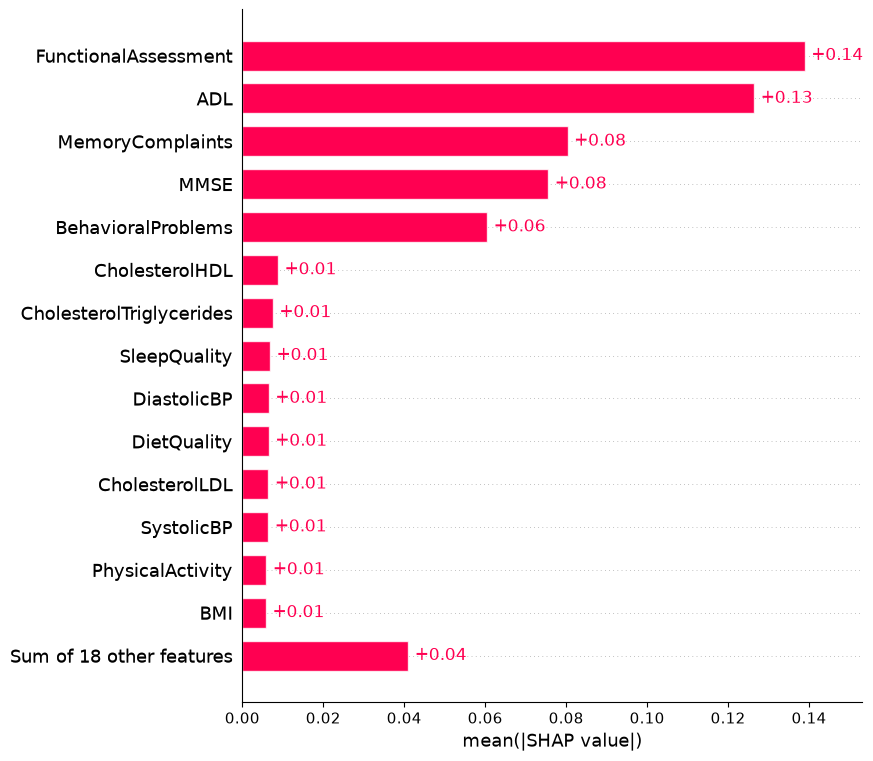

In [16]:
shap.plots.bar(shap_values[:, :, 1], max_display=15)

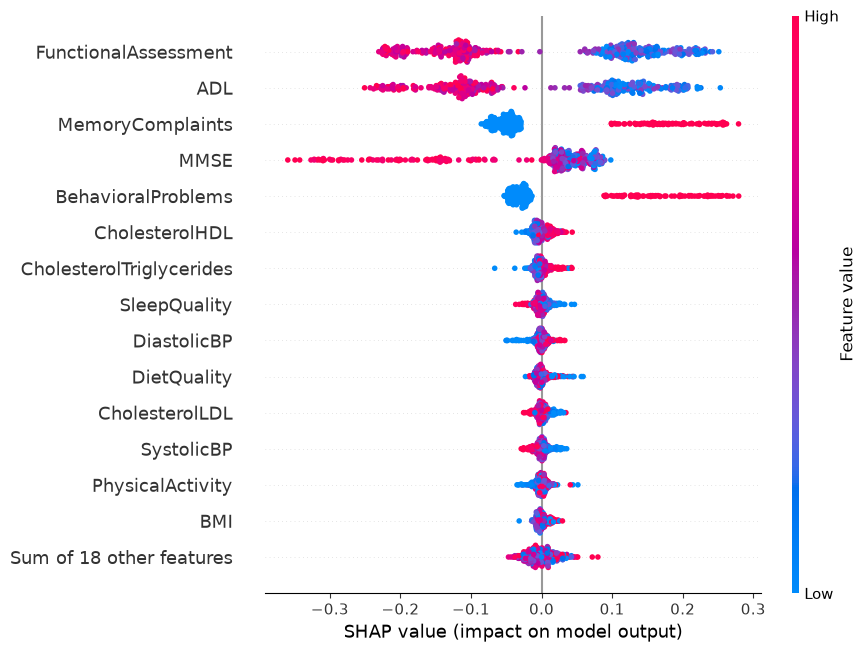

In [17]:
shap.plots.beeswarm(shap_values[:, :, 1], max_display=15)